In [2]:
! pip install transformers

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch # machine learning framework
import torch.nn as nn # neural network module
from sklearn.model_selection import train_test_split # for splitting data into training and testing sets
from sklearn.metrics import classification_report # for evaluating the performance of the model
import transformers # for using pre-trained language models
from transformers import AutoModel, BertTokenizerFast # for using BERT model and tokenizer

In [ ]:
# Check if GPU is available and set the device accordingly
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu") 

Load Dataset

In [3]:
df = pd.read_csv("data/spamdata_v2.csv")
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.shape # check the number of rows and columns in the dataset

(5572, 2)

In [5]:
df['label'].value_counts(normalize = True) # check the distribution of labels in the dataset

label
0    0.865937
1    0.134063
Name: proportion, dtype: float64

Split the dataset into training, validation, and testing sets

In [6]:
# Split the dataset into training, validation, and testing sets
train_text, temp_text, train_labels, temp_labels = train_test_split(df['text'], df['label'],
                                                                    random_state=2018,
                                                                    test_size=0.3,
                                                                    stratify=df['label']) 

# Split the temporary set into validation and testing sets
val_text, test_text, val_labels, test_labels = train_test_split(temp_text, temp_labels,
                                                                random_state=2018,
                                                                test_size=0.5,
                                                                stratify=temp_labels) 

Load the pre-trained BERT model and tokenizer

In [7]:
# Load the pre-trained BERT model and tokenizer
bert = AutoModel.from_pretrained('bert-base-uncased')
# Load the BERT tokenizer
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

d:\Anaconda\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jaysh\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
# Tokenize the text data for the training set
text = [
    "I love AI",
    "BERT is a powerful model",
    "This is a sample sentence"
]

In [10]:
# Tokenize the text data for the training set
sent_id = tokenizer( 
    text, # the text to be tokenized
    padding=True, # pad the text to the maximum length allowed by BERT
    truncation=True, # truncate the text to fit the maximum length allowed by BERT
    return_tensors='pt' # return PyTorch tensors
)

In [ ]:
print(sent_id) # print the tokenized output

{'input_ids': tensor([[  101,  1045,  2293,  9932,   102,     0,     0],
        [  101, 14324,  2003,  1037,  3928,  2944,   102],
        [  101,  2023,  2003,  1037,  7099,  6251,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1]])}


Tokenization

<Axes: >

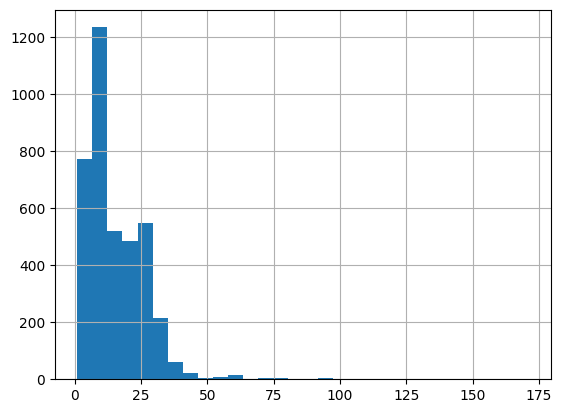

In [12]:
# Analyze the distribution of sequence lengths in the training set
seq_len = [len(i.split()) for i in train_text]

pd.Series(seq_len).hist(bins = 30) # plot a histogram of the sequence lengths

In [13]:
max_seq_len = 25 # set the maximum sequence length for BERT

In [14]:
tokens_train = tokenizer( # tokenize the training text data
    train_text.tolist(), # the text to be tokenized
    max_length=max_seq_len, # set the maximum sequence length for BERT
    padding='max_length', # pad the text to the maximum length specified by max_length
    truncation=True, # truncate the text to fit the maximum length specified by max_length
    return_token_type_ids=False, # do not return token type ids (not needed for single sentence classification)
    return_tensors='pt'   # use 'pt' in your current environment
)

tokens_val = tokenizer( # tokenize the validation text data
    val_text.tolist(),
    max_length=max_seq_len,
    padding='max_length',
    truncation=True,
    return_token_type_ids=False,
    return_tensors='pt'
)

tokens_test = tokenizer( # tokenize the testing text data
    test_text.tolist(),
    max_length=max_seq_len,
    padding='max_length',
    truncation=True,
    return_token_type_ids=False,
    return_tensors='pt'
)

Convert Integer Sequences to Tensors

In [15]:
# for train set
train_seq = torch.tensor(tokens_train['input_ids']) # convert the input ids to a PyTorch tensor
train_mask = torch.tensor(tokens_train['attention_mask']) # convert the attention mask to a PyTorch tensor
train_y = torch.tensor(train_labels.tolist()) # convert the labels to a PyTorch tensor

# for validation set
val_seq = torch.tensor(tokens_val['input_ids']) # convert the input ids to a PyTorch tensor
val_mask = torch.tensor(tokens_val['attention_mask']) # convert the attention mask to a PyTorch tensor
val_y = torch.tensor(val_labels.tolist()) # convert the labels to a PyTorch tensor

# for test set
test_seq = torch.tensor(tokens_test['input_ids']) # convert the input ids to a PyTorch tensor
test_mask = torch.tensor(tokens_test['attention_mask']) # convert the attention mask to a PyTorch tensor
test_y = torch.tensor(test_labels.tolist()) # convert the labels to a PyTorch tensor    

C:\Users\jaysh\AppData\Local\Temp\ipykernel_8696\1228510471.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_seq = torch.tensor(tokens_train['input_ids']) # convert the input ids to a PyTorch tensor
C:\Users\jaysh\AppData\Local\Temp\ipykernel_8696\1228510471.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_mask = torch.tensor(tokens_train['attention_mask']) # convert the attention mask to a PyTorch tensor
C:\Users\jaysh\AppData\Local\Temp\ipykernel_8696\1228510471.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_s

Create DataLoaders

In [16]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler # for creating data loaders

batch_size = 32 # define a batch size for training and evaluation

train_data = TensorDataset(train_seq, train_mask, train_y) # wrap the training data tensors into a TensorDataset

train_sampler = RandomSampler(train_data) # create a random sampler for the training data

train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size) # create a DataLoader for the training set

val_data = TensorDataset(val_seq, val_mask, val_y) # wrap the validation data tensors into a TensorDataset

val_sampler = SequentialSampler(val_data) # create a sequential sampler for the validation data (no shuffling for validation)

val_dataloader = DataLoader(val_data, sampler = val_sampler, batch_size=batch_size) # create a DataLoader for the validation set

Freeze BERT Parameters

In [17]:
for param in bert.parameters(): # freeze the parameters of the BERT model to prevent them from being updated during training
    param.requires_grad = False

Define Model Architecture

In [18]:
class BERT_Arch(nn.Module): # define a new class for the BERT architecture that inherits from nn.Module

    def __init__(self, bert): # initialize the class with the BERT model as an argument

      super(BERT_Arch, self).__init__() # call the constructor of the parent class (nn.Module)

      self.bert = bert # assign the BERT model to an instance variable

      self.dropout = nn.Dropout(0.1) # dropout layer to prevent overfitting

      self.relu =  nn.ReLU() # activation function to introduce non-linearity

      self.fc1 = nn.Linear(768,512) # dense layer 1 (fully connected layer) that takes the output of BERT (768-dimensional) and maps it to a 512-dimensional space

      self.fc2 = nn.Linear(512,2) # dense layer 2 (output layer) that maps the 512-dimensional space to the number of classes

      self.softmax = nn.LogSoftmax(dim=1) # softmax activation function to convert the output of the model into probabilities for each class

    def forward(self, sent_id, mask): # define the forward pass of the model that takes the input ids and attention mask as arguments

      outputs = self.bert(sent_id, attention_mask=mask) # pass the input through the BERT model to get the output
      cls_hs = outputs.last_hidden_state[:, 0] # extract the hidden state corresponding to the [CLS] token (the first token in the sequence)

      x = self.fc1(cls_hs) # pass the [CLS] hidden state through the first dense layer

      x = self.relu(x) # apply the ReLU activation function to introduce non-linearity

      x = self.dropout(x) # apply dropout to prevent overfitting

      x = self.fc2(x) # pass the output of the dropout layer through the second dense layer to get the raw output for each class

      x = self.softmax(x) # apply the softmax activation function to convert the raw output into probabilities for each class

      return x # return the output of the model

In [20]:
# Instantiate the BERT_Arch model with the pre-trained BERT model
model = BERT_Arch(bert)

In [21]:
# Move the model to the appropriate device (GPU or CPU)
model = model.to(device)

In [22]:
# Define the optimizer for training the model
from torch.optim import AdamW

In [23]:
# Use the AdamW optimizer, which is a variant of the Adam optimizer that incorporates weight decay for regularization
optimizer = AdamW(model.parameters(), lr = 1e-3)

Find Class Weights

In [24]:
from sklearn.utils.class_weight import compute_class_weight # for computing class weights to handle class imbalance in the dataset
import numpy as np # for numerical operations

class_wts = compute_class_weight( # compute the class weights based on the training labels to handle class imbalance in the dataset
    class_weight='balanced', # specify that the class weights should be balanced based on the frequency of each class in the training data
    classes=np.unique(train_labels), # specify the unique classes in the training labels
    y=train_labels # specify the training labels to compute the class weights
)

print(class_wts) # print the computed class weights to verify that they have been calculated correctly

[0.57743559 3.72848948]


In [25]:
# Convert the class weights to a PyTorch tensor and move it to the appropriate device
weights= torch.tensor(class_wts,dtype=torch.float)
weights = weights.to(device)

In [26]:
# Define the loss function for training the model, using negative log likelihood loss with the computed class weights to handle class imbalance
cross_entropy  = nn.NLLLoss(weight=weights)

In [27]:
# Set the number of epochs for training the model
epochs = 10

Fine-Tune BERT

In [28]:
def train(): # function to train the model

  model.train() # set the model to training mode

  total_loss, total_accuracy = 0, 0 # initialize variables to keep track of the total loss and accuracy during training

  total_preds=[] # empty list to save model predictions

  for step,batch in enumerate(train_dataloader): # iterate over the batches of data in the training DataLoader

    if step % 50 == 0 and not step == 0: # print the progress every 50 batches (excluding the first batch)
      print('  Batch {:>5,}  of  {:>5,}.'.format(step, len(train_dataloader)))

    batch = [r.to(device) for r in batch] # push the batch to GPU

    sent_id, mask, labels = batch # unpack the batch into input ids, attention mask, and labels

    model.zero_grad() # clear previously calculated gradients

    preds = model(sent_id, mask) # get model predictions for the current batch

    loss = cross_entropy(preds, labels) # calculate the loss between the model predictions and the true labels using the defined loss function

    total_loss = total_loss + loss.item() # accumulate the total loss for the epoch by adding the loss of the current batch

    loss.backward() # perform backpropagation to calculate the gradients of the loss with respect to the model parameters

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # clip the gradients to prevent them from exploding (i.e., becoming too large) during training, which can lead to unstable training and poor performance

    optimizer.step() # update the model parameters using the calculated gradients and the defined optimizer

    preds=preds.detach().cpu().numpy() # convert the model predictions from a PyTorch tensor to a NumPy array and move it to the CPU for further processing

    total_preds.append(preds) # append the predictions of the current batch to the total_preds list to keep track of all predictions made during the epoch

  avg_loss = total_loss / len(train_dataloader) # calculate the average loss for the epoch by dividing the total accumulated loss by the number of batches in the training DataLoader

  total_preds  = np.concatenate(total_preds, axis=0) # concatenate the list of predictions into a single NumPy array along the first axis (i.e., stacking the predictions from all batches together)

  return avg_loss, total_preds # return the average loss and the total predictions for the epoch

In [29]:
def evaluate(): # function for evaluating the model

  print("\nEvaluating...")

  model.eval() # set the model to evaluation mode (disables dropout and other training-specific layers)

  total_loss, total_accuracy = 0, 0 # initialize variables to keep track of the total loss and accuracy during evaluation

  total_preds = [] # empty list to save the model predictions during evaluation

  for step,batch in enumerate(val_dataloader): # iterate over the batches of data in the validation DataLoader

    if step % 50 == 0 and not step == 0: # Progress update every 50 batches.

      elapsed = format_time(time.time() - t0) # Calculate elapsed time in minutes and seconds.

      print('  Batch {:>5,}  of  {:>5,}.'.format(step, len(val_dataloader))) # Print progress update.

    batch = [t.to(device) for t in batch] # push the batch to GPU

    sent_id, mask, labels = batch # unpack the batch into input ids, attention mask, and labels

    with torch.no_grad(): # disable gradient calculation for evaluation to save memory and computational resources, since we are not updating the model parameters during evaluation

      preds = model(sent_id, mask) # get model predictions for the current batch during evaluation

      loss = cross_entropy(preds,labels) # calculate the loss between the model predictions and the true labels using the defined loss function during evaluation

      total_loss = total_loss + loss.item() # accumulate the total loss for the evaluation by adding the loss of the current batch

      preds = preds.detach().cpu().numpy() # convert the model predictions from a PyTorch tensor to a NumPy array and move it to the CPU for further processing during evaluation

      total_preds.append(preds) # append the predictions of the current batch to the total_preds list to keep track of all predictions made during evaluation

  avg_loss = total_loss / len(val_dataloader) # calculate the average loss for the evaluation by dividing the total accumulated loss by the number of batches in the validation DataLoader

  total_preds  = np.concatenate(total_preds, axis=0) # concatenate the list of predictions into a single NumPy array along the first axis (i.e., stacking the predictions from all batches together) during evaluation

  return avg_loss, total_preds # return the average loss and the total predictions for the evaluation

Start Model Training

In [30]:
best_valid_loss = float('inf') # set initial loss to infinite to ensure that any valid loss calculated during training will be lower than this initial value, allowing the model to save the best weights based on the validation loss during training

train_losses=[] # empty list to store training loss of each epoch
valid_losses=[] # empty list to store validation loss of each epoch

for epoch in range(epochs): # iterate over the number of epochs for training the model

    print('\n Epoch {:} / {:}'.format(epoch + 1, epochs)) # print the current epoch number and the total number of epochs to keep track of the training progress

    train_loss, _ = train() # train the model for one epoch and get the average training loss for that epoch

    valid_loss, _ = evaluate() # evaluate the model on the validation set and get the average validation loss for that epoch

    if valid_loss < best_valid_loss: # check if the validation loss for the current epoch is lower than the best validation loss recorded so far
        best_valid_loss = valid_loss # if the current validation loss is lower than the best validation loss, update the best validation loss to the current validation loss
        torch.save(model.state_dict(), 'saved_weights.pt') # save the model weights to a file named 'saved_weights.pt' if the current validation loss is the best one observed so far during training

    train_losses.append(train_loss) # append the average training loss for the current epoch to the train_losses list to keep track of the training loss over epochs
    valid_losses.append(valid_loss) # append the average validation loss for the current epoch to the valid_losses list to keep track of the validation loss over epochs

    print(f'\nTraining Loss: {train_loss:.3f}') # print the average training loss for the current epoch, formatted to three decimal places for better readability
    print(f'Validation Loss: {valid_loss:.3f}') # print the average validation loss for the current epoch, formatted to three decimal places for better readability


 Epoch 1 / 10
  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.204
Validation Loss: 0.142

 Epoch 2 / 10
  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.119
Validation Loss: 0.106

 Epoch 3 / 10
  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.107
Validation Loss: 0.102

 Epoch 4 / 10
  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.096
Validation Loss: 0.098

 Epoch 5 / 10
  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.104
Validation Loss: 0.105

 Epoch 6 / 10
  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.118
Validation Loss: 0.116

 Epoch 7 / 10
  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.093
Validation Loss: 0.085

 Epoch 8 / 10
  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.084
Validat

Load Saved Model

In [31]:
# load weights of best model
path = 'saved_weights.pt'
model.load_state_dict(torch.load(path))

<All keys matched successfully>

Get Predictions for Test Data

In [ ]:
# Evaluate the model on the test set to get the predictions for the test data
with torch.no_grad():
  preds = model(test_seq.to(device), test_mask.to(device))
  preds = preds.detach().cpu().numpy()

In [33]:
# Convert the predicted probabilities to class labels by taking the index of the maximum value along the second axis (i.e., the class with the highest probability)
preds = np.argmax(preds, axis = 1)
print(classification_report(test_y, preds))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       724
           1       0.86      0.96      0.91       112

    accuracy                           0.97       836
   macro avg       0.93      0.97      0.95       836
weighted avg       0.98      0.97      0.97       836



In [34]:
pd.crosstab(test_y, preds) # create a confusion matrix to visualize the performance of the model on the test set by comparing the true labels (test_y) with the predicted labels (preds)

col_0,0,1
row_0,,
0,707,17
1,5,107
